# 1. Install libraries

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn imblearn

# 2. Library Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import f1_score, accuracy_score, make_scorer
from imblearn.metrics import geometric_mean_score

#warnings.filterwarnings('ignore')

# 3. Dataset Import

In [4]:

# Loading the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget class names:", data.target_names)

Dataset shape: (569, 30)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Target class names: ['malignant' 'benign']


In [5]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


# 4. Data preprocessing

In [7]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


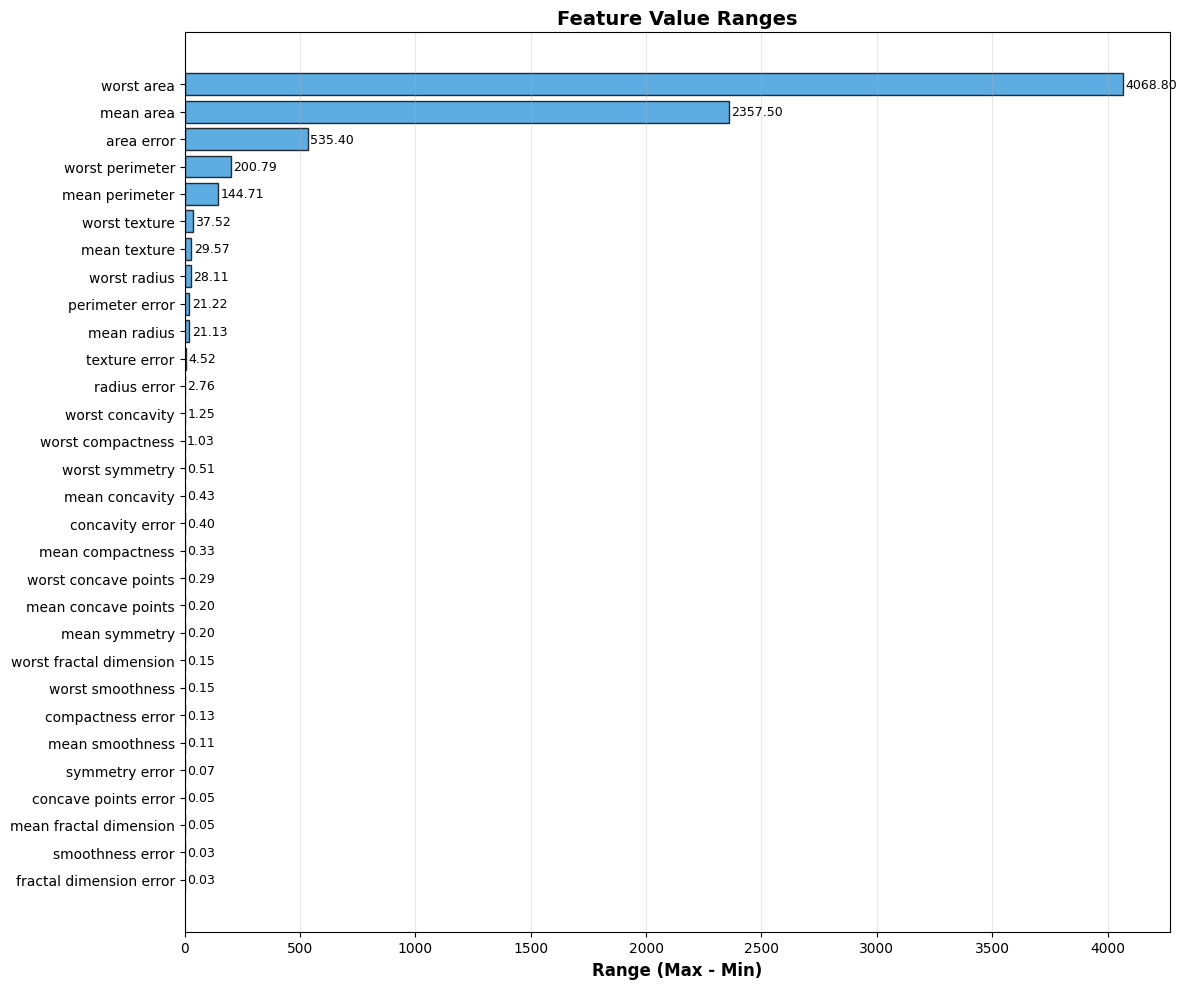

In [8]:
# Check feature scaling

# Calculate min and max for each feature
feature_ranges = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min().values,
    'Max': X.max().values,
    'Range': (X.max() - X.min()).values
})

# Sort by range in descending order
feature_ranges = feature_ranges.sort_values('Range', ascending=True)

# Create barplot
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(feature_ranges))
ax.barh(y_pos, feature_ranges['Range'], color='#3498db', alpha=0.8, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_ranges['Feature'])
ax.set_xlabel('Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_title('Feature Value Ranges', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(feature_ranges.iterrows()):
    ax.text(row['Range'] + 10, i, f"{row['Range']:.2f}", va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

#print("Feature Range Analysis:")
#print(feature_ranges.to_string(index=False))

We will need to apply feature scaling from within the 5-fold CV loop.

# 5. Model Training with 5-Fold Cross Validation


In [9]:
# Initialize Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Import RobustScaler
from sklearn.preprocessing import RobustScaler

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
accuracies = []
f1_scores = []
gmeans = []
train_times = []
test_times = []
feature_importances_list = []

print("Running 5-Fold Cross Validation with Random Forest...\n")

for fold_num, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Apply RobustScaler to training data
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train and evaluate
    start_time = time()
    clf.fit(X_train_scaled, y_train)
    train_time = time() - start_time

    # Store feature importances for this fold
    feature_importances_list.append(clf.feature_importances_)

    start_time = time()
    y_pred = clf.predict(X_test_scaled)
    test_time = time() - start_time

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    gmean = geometric_mean_score(y_test, y_pred, average='weighted')

    accuracies.append(acc)
    f1_scores.append(f1)
    gmeans.append(gmean)
    train_times.append(train_time)
    test_times.append(test_time)

    # print(f"Fold {fold_num}:")
    # print(f"  Accuracy: {acc:.4f}")
    # print(f"  F1-Score: {f1:.4f}")
    # print(f"  G-Mean:   {gmean:.4f}")
    # print()

# Calculate mean feature importances across folds
mean_feature_importances = np.mean(feature_importances_list, axis=0)
std_feature_importances = np.std(feature_importances_list, axis=0)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Importance': mean_feature_importances,
    'Std Importance': std_feature_importances
}).sort_values('Mean Importance', ascending=False)

# print("=" * 80)
# print("MEAN FEATURE IMPORTANCES (Across 5 Folds)")
# print("=" * 80)
# print(feature_importance_df.to_string(index=False))
# print()

# # Aggregate results
# results = {
#     'Classifier': ['Random Forest'],
#     'Accuracy (mean)': [np.mean(accuracies)],
#     'Accuracy (std)': [np.std(accuracies)],
#     'F1-Score (mean)': [np.mean(f1_scores)],
#     'F1-Score (std)': [np.std(f1_scores)],
#     'G-Mean (mean)': [np.mean(gmeans)],
#     'G-Mean (std)': [np.std(gmeans)],
#     'Train Time (s)': [np.mean(train_times)],
#     'Test Time (s)': [np.mean(test_times)]
# }

print("=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(f"Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
print(f"F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"G-Mean:   {np.mean(gmeans):.4f} (+/- {np.std(gmeans):.4f})")
print(f"Avg Train Time: {np.mean(train_times):.6f}s")
print(f"Avg Test Time:  {np.mean(test_times):.6f}s")

Running 5-Fold Cross Validation with Random Forest...

CROSS-VALIDATION SUMMARY
Accuracy: 0.9561 (+/- 0.0123)
F1-Score: 0.9560 (+/- 0.0125)
G-Mean:   0.9526 (+/- 0.0170)
Avg Train Time: 0.320049s
Avg Test Time:  0.010070s


In [10]:
feature_importance_df

,Feature,Mean Importance,Std Importance
23,worst area,0.158870,0.019779
27,worst concave points,0.124576,0.006955
7,mean concave points,0.095846,0.020713
22,worst perimeter,0.090661,0.012187
2,mean perimeter,0.076249,0.010363
20,worst radius,0.071512,0.005836
6,mean concavity,0.058122,0.013637
3,mean area,0.050413,0.008376
0,mean radius,0.044680,0.007172
13,area error,0.034147,0.005583


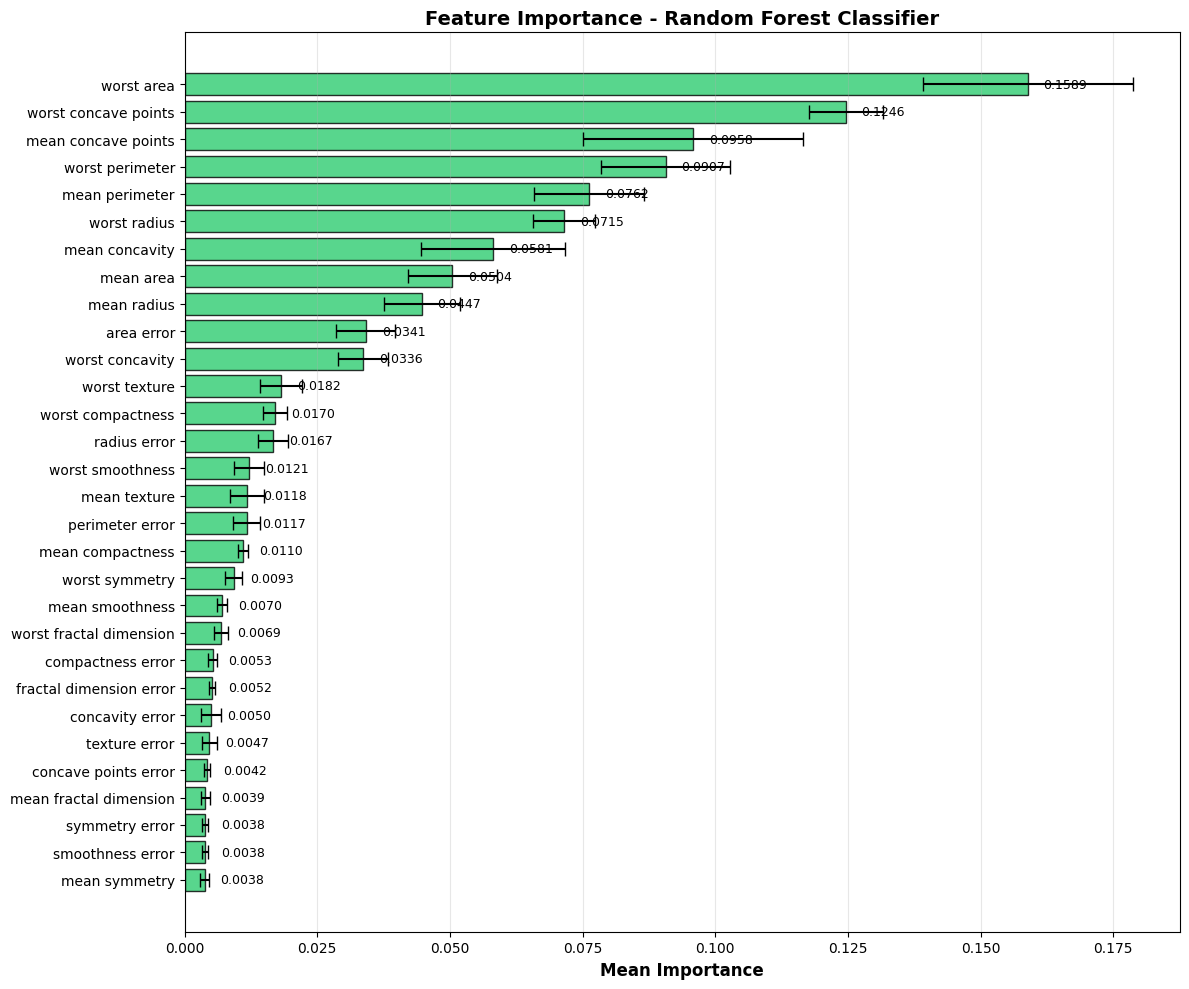

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(feature_importance_df))
ax.barh(y_pos, feature_importance_df['Mean Importance'],
    xerr=feature_importance_df['Std Importance'],
    color='#2ecc71', alpha=0.8, edgecolor='black', capsize=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_importance_df['Feature'])
ax.set_xlabel('Mean Importance', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Add value labels on bars
for i, (idx, row) in enumerate(feature_importance_df.iterrows()):
    ax.text(row['Mean Importance'] + 0.003, i, f"{row['Mean Importance']:.4f}",
        va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Exercício

---

Para essa questão vamos buscar fazer o balanceamento das classes através de uma **pipeline** de normalização e depois de classificação, tal que é uma etapa importante para utilizar o `GridSearchCV` para otimizar os hiperparametros. Como consequencia, a biblioteca Pipeline já foi adicionado e não foi utilizado no processo do treino do 5-fold cross validation no exemplo. Assim, podemos utilizar a mesa para criar uma grade de parametros para busca e continuar com o RandomForest tradicional, tentando reduzir o overfitting (parametro `class_weight='balanced'` também ajuda nessa parte).

#### Configuração, pré-processamento e hiperparametros
---


In [12]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

#### Treino
---


In [13]:
print("Iniciando otimização de hiperparâmetros...")
start = time()
grid_search.fit(X, y)
print(f"Tempo total: {time() - start:.2f}s")

print(f"\nMelhor F1-score médio: {grid_search.best_score_:.4f}")
print(f"Melhores parâmetros: {grid_search.best_params_}")

Iniciando otimização de hiperparâmetros...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tempo total: 122.89s

Melhor F1-score médio: 0.9736
Melhores parâmetros: {'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


#### Resultado

---

Veja que melhorou o F1-score em 0.02 (com StratifiedKFold) em relação ao exemplo, tendo em vista os melhores parâmetros `{'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__min_samples_split': 2, 'rf__n_estimators': 300}`, agora vamos fazer a validação cruzada para ver o resultado dos testes.

In [14]:
cv_results = cross_validate(
    grid_search.best_estimator_,
    X, y,
    cv=cv,
    scoring=['f1', 'accuracy', 'precision', 'recall']
)


print("\n--- Performance Média Final (Validação Cruzada) ---")
print(f"F1-Score:  {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
print(f"Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")

#Adicionando nos resultados
results_alg = pd.DataFrame({
    'name': ['Random Forest'],
    'f1-score': [cv_results['test_f1'].mean()],
    'recall': [cv_results['test_recall'].mean()],
    'precision': [cv_results['test_precision'].mean()]
})


--- Performance Média Final (Validação Cruzada) ---
F1-Score:  0.9736 (+/- 0.0089)
Recall:    0.9776
Precision: 0.9706


### Outros Algoritmos
---

Verificando as bibliotecas comentadas, irei fazer o teste para todas aquelas para ver o desempenho em outros algoritmos. Além disso, basta usar o mesmo `cv` (StratifiedKFold(n_splits=5, shuffle=True, random_state=42)) para os proximos. No fim irei mostrar dos resultados dos algortimos.

In [15]:
# LogisticRegression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=10000
    ))
])


param_grid_lr = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'saga']
}


grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring='f1',
    cv=cv, # Está definido lá no GridSearchCV
    n_jobs=-1
)

print("Otimizando Regressão Logística...")
grid_lr.fit(X, y)

cv_results = cross_validate(
    grid_lr.best_estimator_,
    X, y,
    cv=cv, #CV pode ser o mesmo
    scoring=['f1', 'accuracy', 'precision', 'recall']
)

results_alg = pd.concat([results_alg,
              pd.DataFrame({
                    'name': ['Regressão logistica'],
                    'f1-score': [cv_results['test_f1'].mean()],
                    'recall': [cv_results['test_recall'].mean()],
                    'precision': [cv_results['test_precision'].mean()]
                })], ignore_index=True)

print(f"\nMelhores Parâmetros: {grid_lr.best_params_}")

Otimizando Regressão Logística...

Melhores Parâmetros: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'saga'}


In [16]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        random_state=42,
        class_weight='balanced',
        probability=True
    ))
])


param_grid_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svm__kernel': ['rbf', 'poly', 'sigmoid']
}


grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=cv, # Está definido lá no GridSearchCV
    n_jobs=-1
)


print("Otimizando Support Vector Machine...")
grid_svm.fit(X, y)


cv_results = cross_validate(
    grid_svm.best_estimator_,
    X, y,
    cv=cv, # O mesmo
    scoring=['f1', 'accuracy', 'precision', 'recall']
)

print(f"\nMelhores Parâmetros: {grid_svm.best_params_}")

results_alg = pd.concat([results_alg,
              pd.DataFrame({
                    'name': ['SVM'],
                    'f1-score': [cv_results['test_f1'].mean()],
                    'recall': [cv_results['test_recall'].mean()],
                    'precision': [cv_results['test_precision'].mean()]
                })], ignore_index=True)

Otimizando Support Vector Machine...

Melhores Parâmetros: {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}


In [17]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv, # Está definido lá no GridSearchCV
    n_jobs=-1
)


print("Otimizando K-Nearest Neighbors...")
grid_knn.fit(X, y)

cv_results = cross_validate(
    grid_knn.best_estimator_,
    X, y,
    cv=cv, # O mesmo
    scoring=['f1', 'accuracy', 'precision', 'recall']
)

print(f"\nMelhores Parâmetros: {grid_knn.best_params_}")

results_alg = pd.concat([results_alg,
              pd.DataFrame({
                    'name': ['KNN'],
                    'f1-score': [cv_results['test_f1'].mean()],
                    'recall': [cv_results['test_recall'].mean()],
                    'precision': [cv_results['test_precision'].mean()]
                })], ignore_index=True)

Otimizando K-Nearest Neighbors...

Melhores Parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}


In [18]:
print(f"-------------------- Performance Média --------------------")
results_alg.head()

-------------------- Performance Média --------------------


,name,f1-score,recall,precision
0,Random Forest,0.973608,0.977621,0.970585
1,Regressão logistica,0.980412,0.983216,0.978216
2,SVM,0.986050,0.988772,0.983598
3,KNN,0.975394,0.991667,0.960240


O melhor algoritmo para o **f1-score** foi o **SVM** com 98,60% de f1-score